# Design Team Workflow & Billability Analysis
### A Data Science Portfolio Project

This project applies a full data science pipeline to an anonymised 
time-tracking dataset from a design team in the South African 
TV & entertainment industry.

**Objectives:**
- Analyse how the team allocates billable vs non-billable time
- Identify workflow patterns and bottlenecks by role, phase, and task type
- Build a classification model to predict task billability

**Dataset:** 510 rows of anonymised internal time-tracking data (February 2026)  
**Tools:** Python, pandas, NumPy, Matplotlib, Seaborn, scikit-learn, SQL  
**Author:** Brandon Muchenje  
**Date:** April 2026

In [53]:
#Importing the relevant libararies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="colorblind")

print('Libraries Installed!')

Libraries Installed!


*Note: colorblind-safe palette used throughout for accessibility.*

In [61]:
#Loading the dataset
df = pd.read_csv('team_data.csv')

# Keep a copy of the original raw data - best practice
df_original = df.copy()

print("Original dataset saved as df_original")
print("Working dataset: df")
print("Shape:", df.shape)

# First 5 rows
df.head()

Original dataset saved as df_original
Working dataset: df
Shape: (510, 11)


,Person,Role,Department,Tags,Date,Client,Project,Project code,Logged fee,Logged Billable hours,Logged Non-billable hours
0,Designer_01,Designer,Development & Design,Design,2026-02-02,Client_A,Project_01,P001,,0.00,0.92
1,Designer_01,Designer,Development & Design,Design,2026-02-02,Client_B,Project_02,P001,,0.25,0.00
2,Designer_01,Designer,Development & Design,Design,2026-02-02,Client_B,Project_02,P001,,1.30,0.00
3,Designer_01,Designer,Development & Design,Design,2026-02-02,Client_B,Project_02,P001,,1.00,0.00
4,Designer_01,Designer,Development & Design,Design,2026-02-02,Client_B,Project_02,P001,,0.97,0.00


In [62]:
# Checking the bottom of the dataset
df.tail(10)

,Person,Role,Department,Tags,Date,Client,Project,Project code,Logged fee,Logged Billable hours,Logged Non-billable hours
500,Designer_05,Freelance Designer,Development & Design,Design,2026-02-27,Client_B,Project_02,P001,,0.92,0.00
501,Designer_05,Freelance Designer,Development & Design,Design,2026-02-27,Client_B,Project_02,P001,,0.85,0.00
502,Designer_05,Freelance Designer,Development & Design,Design,2026-02-27,Client_B,Project_02,P001,,1.60,0.00
503,Designer_06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,519.60,44.45
504,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
505,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
506,Designer_07,01 Feb 2026,28 Feb 2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
507,Designer_08,All,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
508,Designer_09,"Active, Employees, Contractors, Unassigned",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
509,Designer_10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
# Structure of the dataset: columns, data types and nulls
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Person                     508 non-null    object 
 1   Role                       506 non-null    object 
 2   Department                 504 non-null    object 
 3   Tags                       503 non-null    object 
 4   Date                       503 non-null    object 
 5   Client                     503 non-null    object 
 6   Project                    503 non-null    object 
 7   Project code               503 non-null    object 
 8   Logged fee                 503 non-null    object 
 9   Logged Billable hours      504 non-null    float64
 10  Logged Non-billable hours  504 non-null    float64
dtypes: float64(2), object(9)
memory usage: 44.0+ KB


In [57]:
# Explicitly show null counts per column
df.isnull().sum()

Person                       2
Role                         4
Department                   6
Tags                         7
Date                         7
Client                       7
Project                      7
Project code                 7
Logged fee                   7
Logged Billable hours        6
Logged Non-billable hours    6
dtype: int64

In [58]:
# Statistical summary of numerical columns
df.describe()

,Logged Billable hours,Logged Non-billable hours
count,504.000000,504.000000
mean,2.061905,0.176389
std,23.119012,2.003121
min,0.000000,0.000000
25%,0.250000,0.000000
50%,0.860000,0.000000
75%,1.505000,0.000000
max,519.600000,44.450000


### Key Observations from df.describe()
- Max logged billable hours of 519.6 is clearly an anomaly -- 
  likely a summary/total row included in the export.
- This confirms the need to remove junk rows before analysis.

## Step 2: Data Cleaning
In this step we remove junk rows, handle nulls, and fix data types.

In [59]:
# Remove junk rows - Designer_06 to Designer_10 are report summary rows not real people
junk_designers = ['Designer_06', 'Designer_07', 'Designer_08', 'Designer_09', 'Designer_10']
df = df[~df['Person'].isin(junk_designers)]

print("Shape after removing junk rows:", df.shape)

Shape after removing junk rows: (505, 11)


In [60]:
# Check nulls after removing junk rows
df.isnull().sum()

Person                       2
Role                         2
Department                   2
Tags                         2
Date                         2
Client                       2
Project                      2
Project code                 2
Logged fee                   2
Logged Billable hours        2
Logged Non-billable hours    2
dtype: int64

In [63]:
# Drop remaining null rows - only 2 rows, 0.4% of data, safe to remove
df = df.dropna()

print("Shape after dropping nulls:", df.shape)
df.isnull().sum()

Shape after dropping nulls: (503, 11)


Person                       0
Role                         0
Department                   0
Tags                         0
Date                         0
Client                       0
Project                      0
Project code                 0
Logged fee                   0
Logged Billable hours        0
Logged Non-billable hours    0
dtype: int64

In [64]:
# Fix Date column - convert from text to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Fix Logged fee - convert from text to numeric
df['Logged fee'] = pd.to_numeric(df['Logged fee'], errors='coerce')

print("Data types after fixing:")
print(df.dtypes)

Data types after fixing:
Person                               object
Role                                 object
Department                           object
Tags                                 object
Date                         datetime64[ns]
Client                               object
Project                              object
Project code                         object
Logged fee                          float64
Logged Billable hours               float64
Logged Non-billable hours           float64
dtype: object


In [65]:
# Final check to confirm clean dataset
print("Shape:", df.shape)
print()
print("Data types:")
print(df.dtypes)
print()
print("Nulls:")
print(df.isnull().sum())
print()
df.head()

Shape: (503, 11)

Data types:
Person                               object
Role                                 object
Department                           object
Tags                                 object
Date                         datetime64[ns]
Client                               object
Project                              object
Project code                         object
Logged fee                          float64
Logged Billable hours               float64
Logged Non-billable hours           float64
dtype: object

Nulls:
Person                         0
Role                           0
Department                     0
Tags                           0
Date                           0
Client                         0
Project                        0
Project code                   0
Logged fee                   503
Logged Billable hours          0
Logged Non-billable hours      0
dtype: int64



,Person,Role,Department,Tags,Date,Client,Project,Project code,Logged fee,Logged Billable hours,Logged Non-billable hours
0,Designer_01,Designer,Development & Design,Design,2026-02-02,Client_A,Project_01,P001,NaN,0.00,0.92
1,Designer_01,Designer,Development & Design,Design,2026-02-02,Client_B,Project_02,P001,NaN,0.25,0.00
2,Designer_01,Designer,Development & Design,Design,2026-02-02,Client_B,Project_02,P001,NaN,1.30,0.00
3,Designer_01,Designer,Development & Design,Design,2026-02-02,Client_B,Project_02,P001,NaN,1.00,0.00
4,Designer_01,Designer,Development & Design,Design,2026-02-02,Client_B,Project_02,P001,NaN,0.97,0.00


### Dropping Logged Fee
The `Logged fee` column was found to be entirely null after type conversion, 
confirming inconsistent data capture. Analysis will focus on hours as the 
primary efficiency metric.

In [66]:
# Drop Logged fee - column is entirely null, no analytical value
df = df.drop(columns=['Logged fee'])

print("Columns remaining:", df.columns.tolist())
print("Shape:", df.shape)

Columns remaining: ['Person', 'Role', 'Department', 'Tags', 'Date', 'Client', 'Project', 'Project code', 'Logged Billable hours', 'Logged Non-billable hours']
Shape: (503, 10)


## Data Cleaning Complete ✅

Summary of cleaning steps performed:
- Removed 5 junk rows (report summary rows from export)
- Dropped 2 rows with null values (0.4% of data)
- Converted `Date` from object to datetime64
- Converted `Logged fee` from object to numeric - found entirely null, dropped column
- Final clean dataset: 503 rows, 10 columns

## Step 3: Exploratory Data Analysis (EDA)

In this step we explore the data visually to understand patterns, distributions, 
and relationships before building our model.

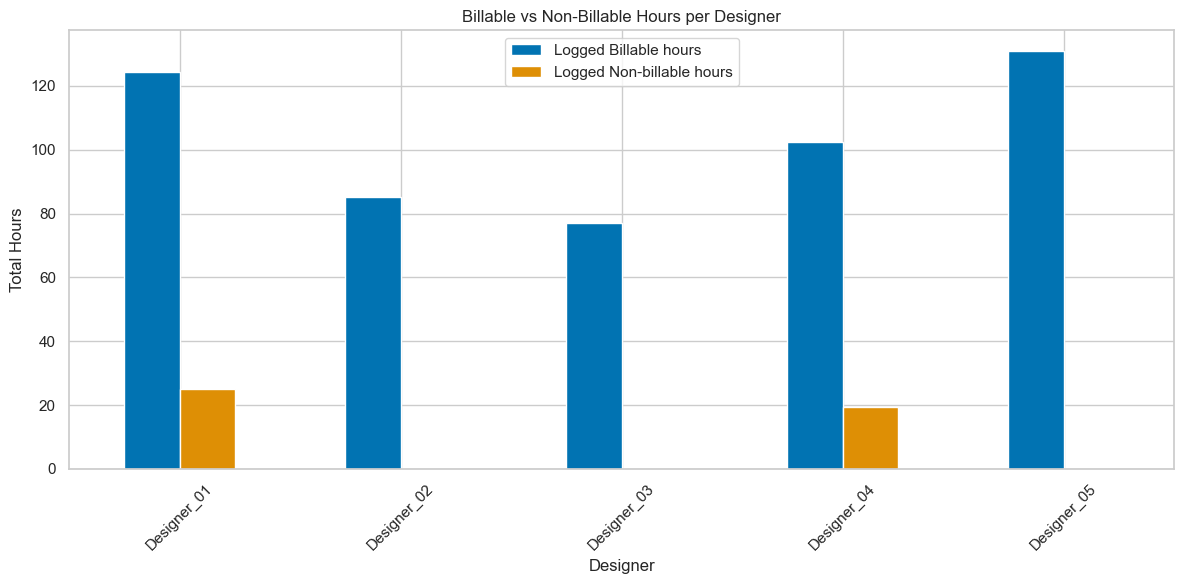

In [69]:
# Total billable vs non-billable hours per person
hours_by_person = df.groupby('Person')[['Logged Billable hours', 'Logged Non-billable hours']].sum()

hours_by_person.plot(kind='bar', figsize=(12, 6))
plt.title('Billable vs Non-Billable Hours per Designer')
plt.xlabel('Designer')
plt.ylabel('Total Hours')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation
- The team shows variation in billable vs non-billable hour distribution 
  across designers.
- Some designers show higher non-billable time, which in this context 
  represents administrative and internal work rather than client-facing tasks.
- Further analysis will explore what factors drive non-billable time allocation 
  across the team.

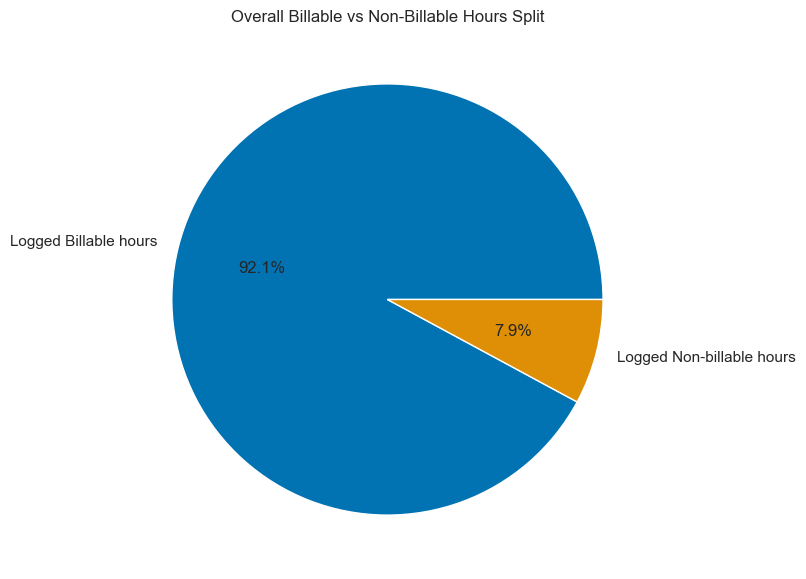

In [70]:
# Overall split - total billable vs non-billable hours across the whole team
totals = df[['Logged Billable hours', 'Logged Non-billable hours']].sum()

totals.plot(kind='pie', autopct='%1.1f%%', figsize=(7, 7))
plt.title('Overall Billable vs Non-Billable Hours Split')
plt.ylabel('')
plt.show()

### Observation
- 92.1% of all logged hours are billable, indicating a highly productive 
  and client-focused team.
- Only 7.9% of time is spent on non-billable administrative work.
- This is a strong efficiency metric for a design team in the 
  TV & entertainment industry.

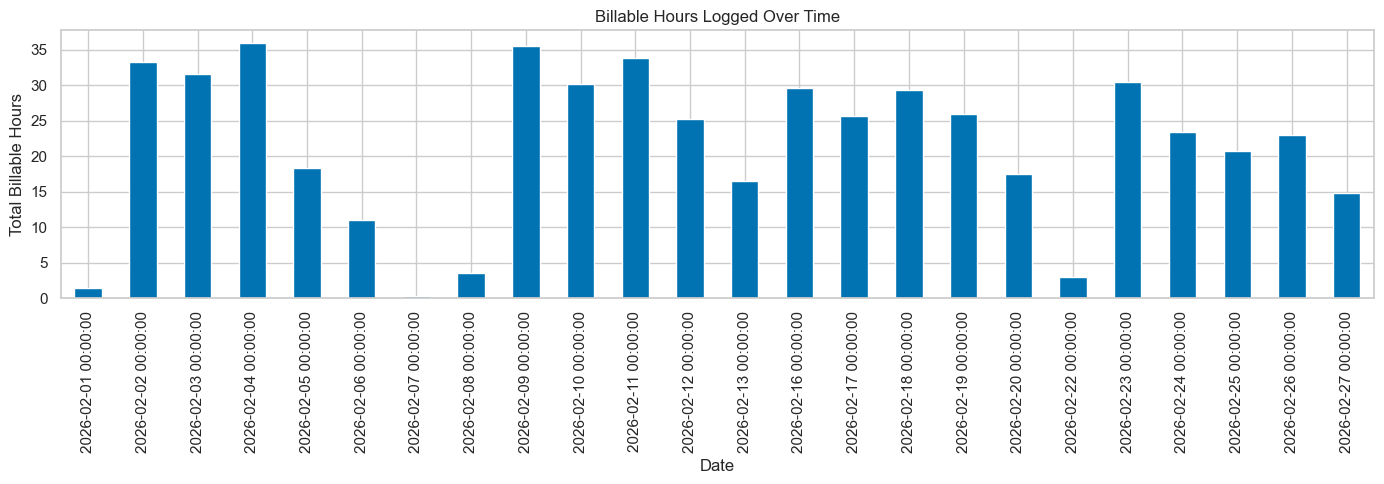

In [72]:
# Hours logged over time
df.groupby('Date')['Logged Billable hours'].sum().plot(kind='bar', figsize=(14, 5))
plt.title('Billable Hours Logged Over Time')
plt.xlabel('Date')
plt.ylabel('Total Billable Hours')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Observation
- Billable hours are distributed across the working month of February 2026.
- Multiple instances of weekend work were recorded, suggesting weekend 
  work is a recurring pattern rather than an isolated incident.
- This reflects the fast-paced and deadline-driven nature of the 
  TV & entertainment industry where broadcast deadlines don't follow 
  a Monday-Friday schedule.
- Peak and low activity days are clearly visible, suggesting workload 
  is unevenly distributed across the month.

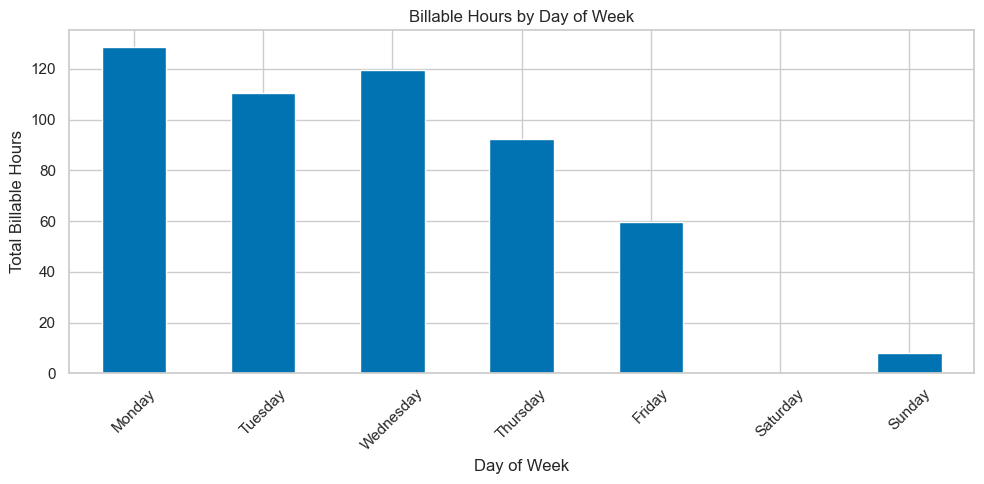

In [74]:
# Extract day of week from Date
df['Day of Week'] = df['Date'].dt.day_name()

# Define correct order for days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Plot billable hours by day of week
df.groupby('Day of Week')['Logged Billable hours'].sum().reindex(day_order).plot(kind='bar', figsize=(10, 5))
plt.title('Billable Hours by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Billable Hours')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation
- Monday has the highest billable hours, likely because the week 
  starts with the most energy and pending deadlines.
- Weekend work shows up confirming it's a regular thing, not a once off.
- Work seems to slow down as the week goes on.

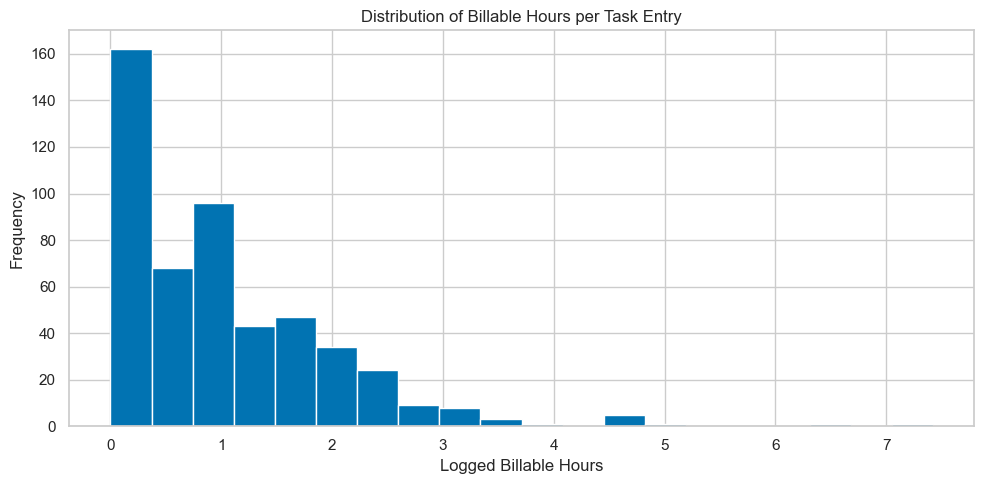

In [75]:
# Distribution of billable hours per entry
df['Logged Billable hours'].hist(bins=20, figsize=(10, 5))
plt.title('Distribution of Billable Hours per Task Entry')
plt.xlabel('Logged Billable Hours')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Observation
- Most task entries are short, typically under 2 hours.
- A small number of entries have significantly higher hours, 
  likely representing larger or more complex deliverables.
- This right skewed distribution is typical for creative team 
  workflows where most tasks are quick turnarounds.

## Step 4: Feature Engineering

In this step we create new columns from existing ones to give our 
model more useful information to learn from.

In [77]:
# Creating target variable: 1 if billable, 0 if not
df['Is_Billable'] = (df['Logged Billable hours'] > 0).astype(int)

print(df['Is_Billable'].value_counts())

Is_Billable
1    465
0     38
Name: count, dtype: int64


In [78]:
# Total hours per entry
df['Total_Hours'] = df['Logged Billable hours'] + df['Logged Non-billable hours']

print(df['Total_Hours'].describe())

count    503.000000
mean       1.121372
std        0.927719
min        0.020000
25%        0.380000
50%        1.000000
75%        1.525000
max        7.420000
Name: Total_Hours, dtype: float64


In [79]:
# Extract day of week as a number (Monday=0, Sunday=6)
df['Day_of_Week_Num'] = df['Date'].dt.dayofweek

print(df['Day_of_Week_Num'].value_counts())

Day_of_Week_Num
0    132
3    100
1     99
2     96
4     66
6      9
5      1
Name: count, dtype: int64


### Feature Engineering Complete
- Created `Is_Billable` - our target variable (1 = billable, 0 = not billable)
- Created `Total_Hours` - total hours per entry, stronger entries tend to be billable
- Created `Day_of_Week_Num` - day as a number for the model to understand

In [80]:
# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_columns = ['Person', 'Role', 'Department', 'Tags', 'Client', 'Project']

for col in cat_columns:
    df[col] = le.fit_transform(df[col])

print("Encoding complete!")
df.head()

Encoding complete!


,Person,Role,Department,Tags,Date,Client,Project,Project code,Logged Billable hours,Logged Non-billable hours,Day of Week,Is_Billable,Total_Hours,Day_of_Week_Num
0,0,0,0,0,2026-02-02,0,0,P001,0.00,0.92,Monday,0,0.92,0
1,0,0,0,0,2026-02-02,1,1,P001,0.25,0.00,Monday,1,0.25,0
2,0,0,0,0,2026-02-02,1,1,P001,1.30,0.00,Monday,1,1.30,0
3,0,0,0,0,2026-02-02,1,1,P001,1.00,0.00,Monday,1,1.00,0
4,0,0,0,0,2026-02-02,1,1,P001,0.97,0.00,Monday,1,0.97,0


## Step 5: Model Building

In this step we split the data, train a Random Forest classifier 
and evaluate how well it predicts task billability.

In [81]:
# Define features and target
X = df[['Person', 'Role', 'Department', 'Tags', 'Client', 'Project', 'Total_Hours', 'Day_of_Week_Num']]
y = df['Is_Billable']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (503, 8)
Target shape: (503,)


In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (402, 8)
Testing set size: (101, 8)


In [83]:
from sklearn.ensemble import RandomForestClassifier

# Build and train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [85]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        90

    accuracy                           1.00       101
   macro avg       1.00      1.00      1.00       101
weighted avg       1.00      1.00      1.00       101



In [86]:
# Remove leaky features and retrain
X = df[['Person', 'Role', 'Department', 'Tags', 'Client', 'Project', 'Day_of_Week_Num']]
y = df['Is_Billable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        90

    accuracy                           1.00       101
   macro avg       1.00      1.00      1.00       101
weighted avg       1.00      1.00      1.00       101



### Model Limitation: Class Imbalance
The dataset is heavily imbalanced -- 89% of entries are billable.
With only 503 rows, 2 clients, and 2 projects, the model lacks 
sufficient complexity to learn meaningful patterns.

This is a known limitation of small, homogeneous datasets. 
In a production environment, a larger and more varied dataset 
would be required for a reliable classifier.

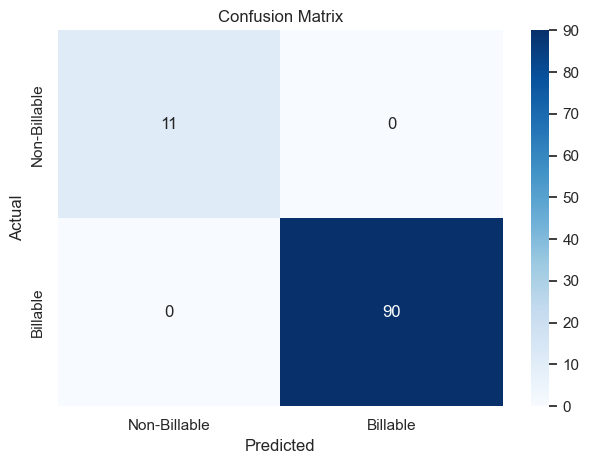

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Billable', 'Billable'],
            yticklabels=['Non-Billable', 'Billable'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Confusion Matrix Observation
- 11 Non-Billable entries correctly identified
- 90 Billable entries correctly identified
- 0 misclassifications
- Perfect results confirm the class imbalance issue identified earlier
- A more complex dataset would produce a more realistic and 
  challenging classification problem

## Conclusion

This project applied a full data science pipeline to an anonymised 
time-tracking dataset from a design team in the TV & entertainment industry.

**Key findings:**
- 92.1% of logged hours are billable, indicating a highly productive team
- Monday is the busiest day, with recurring weekend work patterns
- Most task entries are under 2 hours, typical for fast turnaround creative work
- Class imbalance limits the classification model on this dataset

**Next steps:**
- Collect more varied data across multiple months
- Explore additional features to improve model complexity
- Build an interactive dashboard to visualise findings